In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [26]:
POINTS = np.array([(0,0)]) # Tuple of (bins, pulls) points

i = 100
j = 10
while j <= 1000:
    POINTS = np.append(POINTS, [(i, j)], axis=0)
    j += 30
i += 900
j = 10
while j <= 1000:
    POINTS = np.append(POINTS, [(i, j)], axis=0)
    j += 30

j = 40
i = 50
while i <= 1500:
    POINTS = np.append(POINTS, [(i, j)], axis=0)
    i += 50
j += 600
i = 50
while i <= 1500:
    POINTS = np.append(POINTS, [(i, j)], axis=0)
    i += 50

POINTS = POINTS[1:] # Remove the initial (0,0) point
print(POINTS)

[[ 100   10]
 [ 100   40]
 [ 100   70]
 [ 100  100]
 [ 100  130]
 [ 100  160]
 [ 100  190]
 [ 100  220]
 [ 100  250]
 [ 100  280]
 [ 100  310]
 [ 100  340]
 [ 100  370]
 [ 100  400]
 [ 100  430]
 [ 100  460]
 [ 100  490]
 [ 100  520]
 [ 100  550]
 [ 100  580]
 [ 100  610]
 [ 100  640]
 [ 100  670]
 [ 100  700]
 [ 100  730]
 [ 100  760]
 [ 100  790]
 [ 100  820]
 [ 100  850]
 [ 100  880]
 [ 100  910]
 [ 100  940]
 [ 100  970]
 [ 100 1000]
 [1000   10]
 [1000   40]
 [1000   70]
 [1000  100]
 [1000  130]
 [1000  160]
 [1000  190]
 [1000  220]
 [1000  250]
 [1000  280]
 [1000  310]
 [1000  340]
 [1000  370]
 [1000  400]
 [1000  430]
 [1000  460]
 [1000  490]
 [1000  520]
 [1000  550]
 [1000  580]
 [1000  610]
 [1000  640]
 [1000  670]
 [1000  700]
 [1000  730]
 [1000  760]
 [1000  790]
 [1000  820]
 [1000  850]
 [1000  880]
 [1000  910]
 [1000  940]
 [1000  970]
 [1000 1000]
 [  50   40]
 [ 100   40]
 [ 150   40]
 [ 200   40]
 [ 250   40]
 [ 300   40]
 [ 350   40]
 [ 400   40]
 [ 450   40]

In [ ]:
# dict -> (nbinns, npulls) : [process_time, fill_spectra_all_time, fill_spectra_phys_time, fill_spectra_nuis_time, chi2_no_grad_time, chi2_with_grad_time]

valid_process_times_points = np.array([(0,0)])
valid_fill_spectra_all_times_points = np.array([(0,0)])
valid_fill_spectra_phys_times_points = np.array([(0,0)])
valid_fill_spectra_nuis_times_points = np.array([(0,0)])
valid_chi2_no_grad_times_points = np.array([(0,0)])
valid_chi2_with_grad_times_points = np.array([(0,0)])

times_dict = {}
for bins, pulls in POINTS:
    process_time = -1
    fill_spectra_all_time = -1
    fill_spectra_phys_time = -1
    fill_spectra_nuis_time = -1
    chi2_no_grad_time = -1
    chi2_with_grad_time = -1

    with open(f'./scaling_outputs/scale_{bins}bins_{pulls}pulls.txt', 'r') as f:
        lines = f.readlines()
        for line in lines:
            if 'fillspectra_vary_all' in line:
                line_arr = line.split()
                time = float(line_arr[-1].split('=')[-1])
                fill_spectra_all_time = time
            elif 'fillspectra_vary_phys' in line:
                line_arr = line.split()
                time = float(line_arr[-1].split('=')[-1])
                fill_spectra_phys_time = time
            elif 'fillspectra_vary_nuis' in line:
                line_arr = line.split()
                time = float(line_arr[-1].split('=')[-1])
                fill_spectra_nuis_time = time
            elif 'metric_vary_all' in line:
                line_arr = line.split()
                time = float(line_arr[-1].split('=')[-1])
                chi2_no_grad_time = time
            elif 'metric_grad_vary_all' in line:
                line_arr = line.split()
                time = float(line_arr[-1].split('=')[-1])
                chi2_with_grad_time = time
    f.close()

    with open(f'./time_logs/user_{bins}bins_{pulls}pulls_time.txt', 'r') as f2:
        line = f2.readline()
        time = float(line.split()[1].split('m')[0]) * 60 + float(line.split()[1].split('m')[1].split('s')[0])
        process_time = time
    f2.close()

    times_dict[(bins, pulls)] = [process_time, fill_spectra_all_time, fill_spectra_phys_time, fill_spectra_nuis_time, chi2_no_grad_time, chi2_with_grad_time]

    if process_time != -1:
        valid_process_times_points = np.append(valid_process_times_points, [(bins, pulls)], axis=0)
    if fill_spectra_all_time != -1:
        valid_fill_spectra_all_times_points = np.append(valid_fill_spectra_all_times_points, [(bins, pulls)], axis=0)
    if fill_spectra_phys_time != -1:
        valid_fill_spectra_phys_times_points = np.append(valid_fill_spectra_phys_times_points, [(bins, pulls)], axis=0)
    if fill_spectra_nuis_time != -1:
        valid_fill_spectra_nuis_times_points = np.append(valid_fill_spectra_nuis_times_points, [(bins, pulls)], axis=0)
    if chi2_no_grad_time != -1:
        valid_chi2_no_grad_times_points = np.append(valid_chi2_no_grad_times_points, [(bins, pulls)], axis=0)
    if chi2_with_grad_time != -1:
        valid_chi2_with_grad_times_points = np.append(valid_chi2_with_grad_times_points, [(bins, pulls)], axis=0)
    
valid_process_times_points = valid_process_times_points[1:]
valid_fill_spectra_all_times_points = valid_fill_spectra_all_times_points[1:]
valid_fill_spectra_phys_times_points = valid_fill_spectra_phys_times_points[1:]
valid_fill_spectra_nuis_times_points = valid_fill_spectra_nuis_times_points[1:]
valid_chi2_no_grad_times_points = valid_chi2_no_grad_times_points[1:]
valid_chi2_with_grad_times_points = valid_chi2_with_grad_times_points[1:]

In [ ]:
process_times = np.array([])
fill_spectra_all_times = np.array([])
fill_spectra_phys_times = np.array([])
fill_spectra_nuis_times = np.array([])
chi2_no_grad_times = np.array([])
chi2_with_grad_times = np.array([])

for bins, pulls in valid_process_times_points:
    process_times = np.append(process_times, times_dict[(bins, pulls)][0])

for bins, pulls in valid_fill_spectra_all_times_points:
    fill_spectra_all_times = np.append(fill_spectra_all_times, times_dict[(bins, pulls)][1])

for bins, pulls in valid_fill_spectra_phys_times_points:
    fill_spectra_phys_times = np.append(fill_spectra_phys_times, times_dict[(bins, pulls)][2])

for bins, pulls in valid_fill_spectra_nuis_times_points:
    fill_spectra_nuis_times = np.append(fill_spectra_nuis_times, times_dict[(bins, pulls)][3])

for bins, pulls in valid_chi2_no_grad_times_points:
    chi2_no_grad_times = np.append(chi2_no_grad_times, times_dict[(bins, pulls)][4])

for bins, pulls in valid_chi2_with_grad_times_points:
    chi2_with_grad_times = np.append(chi2_with_grad_times, times_dict[(bins, pulls)][5])

In [ ]:
def exponential_func(x, a, b):
    return a * np.exp(b * x)

def quadratic_func(x, a, b, c):
    return a * x**2 + b * x + c

params_exp, covar_exp = curve_fit(exponential_func, valid_fill_spectra_all_times_points[:, 0], fill_spectra_all_times, p0=(100, 0.006))
exp_residuals = fill_spectra_all_times - exponential_func(valid_fill_spectra_all_times_points[:, 0], *params_exp)
exp_ss_res = np.sum(exp_residuals**2)
exp_ss_tot = np.sum((fill_spectra_all_times - np.mean(fill_spectra_all_times))**2)
exp_r_squared = 1 - (exp_ss_res / exp_ss_tot)

params_quad, covar_quad = curve_fit(quadratic_func, valid_fill_spectra_all_times_points[:, 0], fill_spectra_all_times)
quad_residuals = fill_spectra_all_times - quadratic_func(valid_fill_spectra_all_times_points[:, 0], *params_quad)
quad_ss_res = np.sum(quad_residuals**2)
quad_ss_tot = np.sum((fill_spectra_all_times - np.mean(fill_spectra_all_times))**2)
quad_r_squared = 1 - (quad_ss_res / quad_ss_tot)

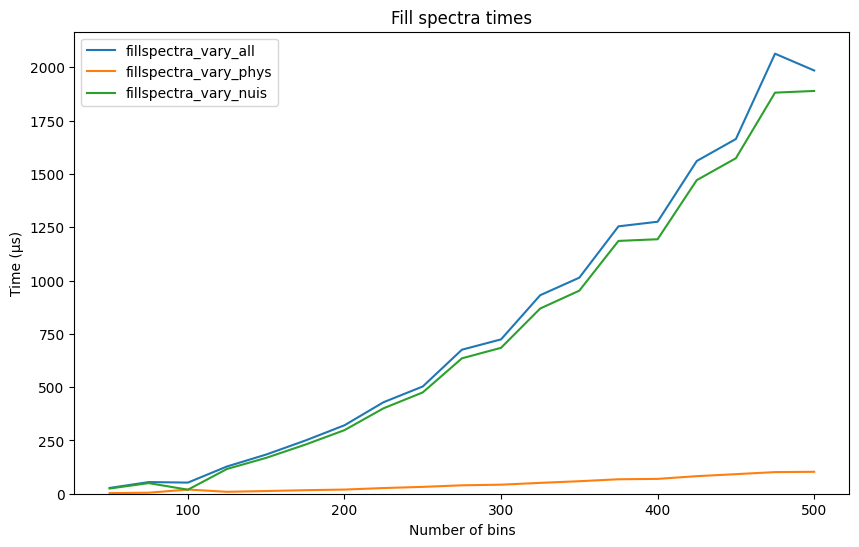

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(valid_fill_spectra_all_times_points[:, 0], fill_spectra_all_times, label='fillspectra_vary_all')
plt.scatter(valid_fill_spectra_phys_times_points[:, 0], fill_spectra_phys_times, label='fillspectra_vary_phys')
plt.scatter(valid_fill_spectra_nuis_times_points[:, 0], fill_spectra_nuis_times, label='fillspectra_vary_nuis')
plt.legend()
plt.xlabel('Number of bins')
plt.ylabel('Time (μs)')
plt.title('Fill spectra times')
plt.ylim(0,)
plt.show()

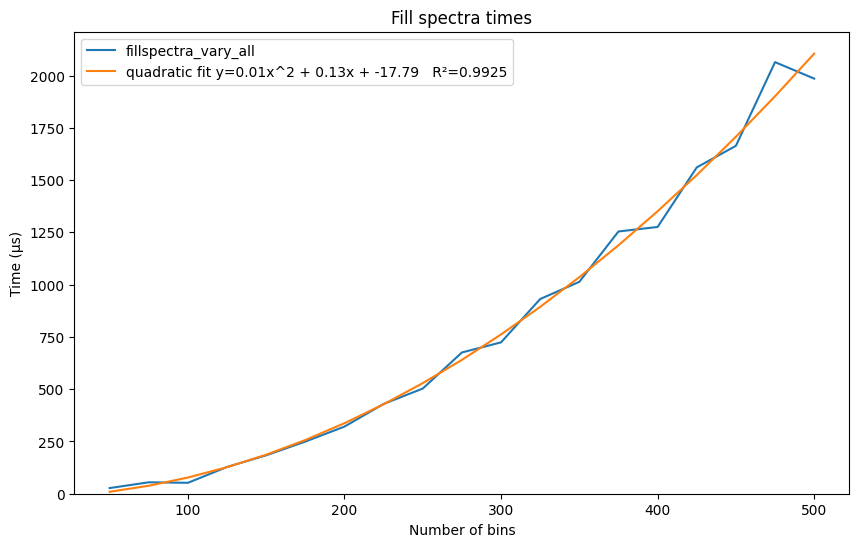

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(valid_fill_spectra_all_times_points[:, 0], fill_spectra_all_times, label='fillspectra_vary_all')
#plt.plot(POINTS[:, 0], exponential_func(POINTS[:, 0], *params_exp), label='exponential fit y=%.2fe^(%.4fx)        R²=%.4f' % (*tuple(params_exp), exp_r_squared))
plt.plot(sorted(valid_fill_spectra_all_times_points[:, 0]), quadratic_func(sorted(valid_fill_spectra_all_times_points[:, 0]), *params_quad), label='quadratic fit y=%.2fx^2 + %.2fx + %.2f   R²=%.4f' % (*tuple(params_quad), quad_r_squared))
plt.legend()
plt.xlabel('Number of bins')
plt.ylabel('Time (μs)')
plt.title('Fill spectra times')
plt.ylim(0,)
plt.show()

In [ ]:
chi_quad_params, chi_covar_quad = curve_fit(quadratic_func, valid_chi2_with_grad_times_points[:, 0], chi2_with_grad_times)
chi_quad_residuals = chi2_with_grad_times - quadratic_func(valid_chi2_with_grad_times_points[:, 0], *chi_quad_params)
chi_quad_ss_res = np.sum(chi_quad_residuals**2)
chi_quad_ss_tot = np.sum((chi2_with_grad_times - np.mean(chi2_with_grad_times))**2)
chi_quad_r_squared = 1 - (chi_quad_ss_res / chi_quad_ss_tot)

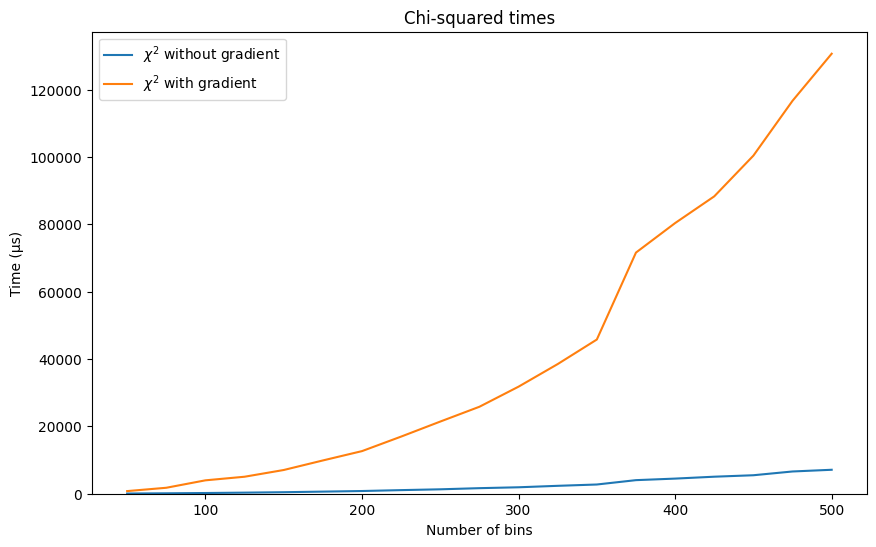

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(valid_chi2_no_grad_times_points[:, 0], chi2_no_grad_times, label='$\\chi^2$ without gradient')
plt.plot(valid_chi2_with_grad_times_points[:, 0], chi2_with_grad_times, label='$\\chi^2$ with gradient')
plt.legend()
plt.xlabel('Number of bins')
plt.ylabel('Time (μs)')
plt.title('Chi-squared times')
plt.ylim(0,)
plt.show()

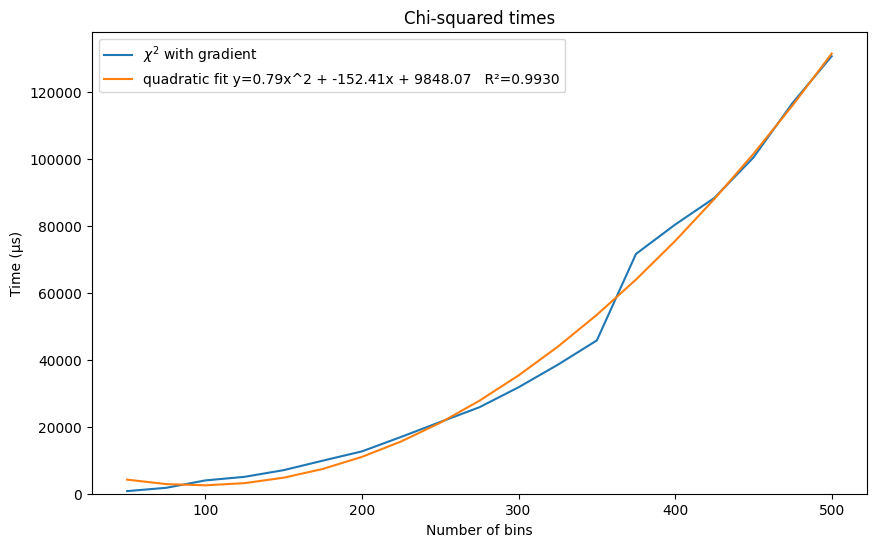

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(valid_chi2_with_grad_times_points[:, 0], chi2_with_grad_times, label='$\\chi^2$ with gradient')
plt.plot(sorted(valid_chi2_with_grad_times_points[:, 0]), quadratic_func(sorted(valid_chi2_with_grad_times_points[:, 0]), *chi_quad_params), label='quadratic fit y=%.2fx^2 + %.2fx + %.2f   R²=%.4f' % (*tuple(chi_quad_params), chi_quad_r_squared))
plt.legend()
plt.xlabel('Number of bins')
plt.ylabel('Time (μs)')
plt.title('Chi-squared times')
plt.ylim(0,)
plt.show()

In [ ]:
def sqrt_func(x, a, b):
    return a * np.sqrt(x) + b

def log_func(x, a, b):
    return a * np.log(x) + b

sqrt_params, sqrt_covar = curve_fit(sqrt_func, valid_process_times_points[:, 0], process_times)
sqrt_residuals = process_times - sqrt_func(valid_process_times_points[:, 0], *sqrt_params)
sqrt_ss_res = np.sum(sqrt_residuals**2)
sqrt_ss_tot = np.sum((process_times - np.mean(process_times))**2)
sqrt_r_squared = 1 - (sqrt_ss_res / sqrt_ss_tot)

log_params, log_covar = curve_fit(log_func, valid_process_times_points[:, 0], process_times)
log_residuals = process_times - log_func(valid_process_times_points[:, 0], *log_params)
log_ss_res = np.sum(log_residuals**2)
log_ss_tot = np.sum((process_times - np.mean(process_times))**2)
log_r_squared = 1 - (log_ss_res / log_ss_tot)

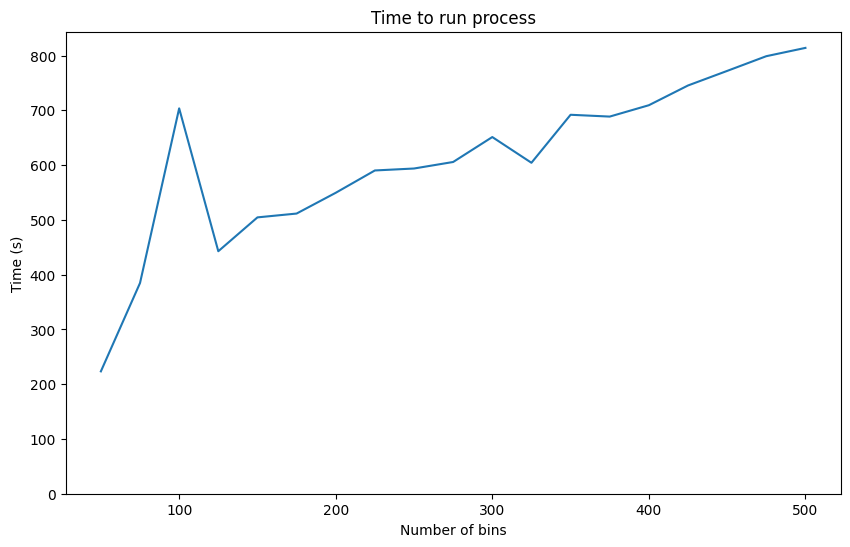

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(valid_process_times_points[:, 0], process_times)
plt.xlabel('Number of bins')
plt.ylabel('Time (s)')
plt.title('Time to run process')
plt.ylim(0,)
plt.show()

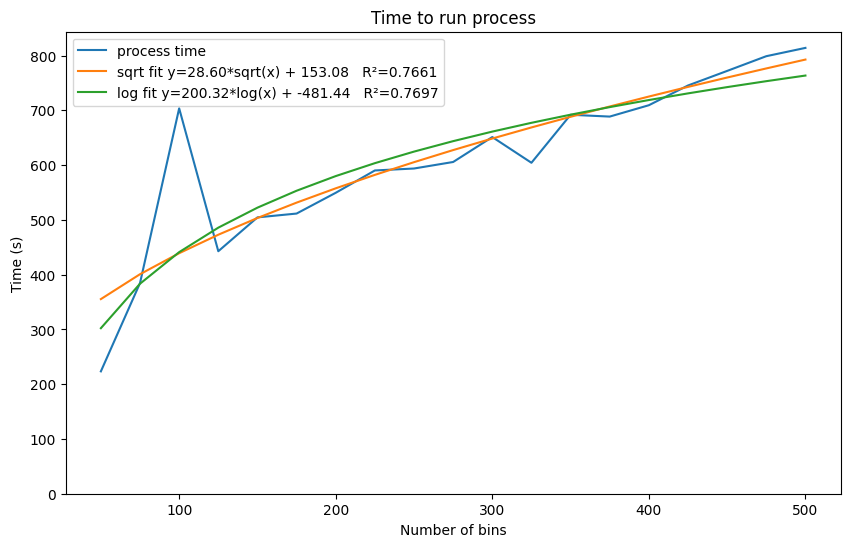

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(valid_process_times_points[:, 0], process_times, label='process time')
plt.plot(sorted(valid_process_times_points[:, 0]), sqrt_func(sorted(valid_process_times_points[:, 0]), *sqrt_params), label='sqrt fit y=%.2f*sqrt(x) + %.2f   R²=%.4f' % (*tuple(sqrt_params), sqrt_r_squared))
plt.plot(sorted(valid_process_times_points[:, 0]), log_func(sorted(valid_process_times_points[:, 0]), *log_params), label='log fit y=%.2f*log(x) + %.2f   R²=%.4f' % (*tuple(log_params), log_r_squared))
plt.legend()
plt.xlabel('Number of bins')
plt.ylabel('Time (s)')
plt.title('Time to run process')
plt.ylim(0,)
plt.show()

In [13]:
# 20 norms vs 20 splines and 10 norms vs 10 splines to see if they take the same time to run with the same number of bins
# Also check if repeating the same name for splines could work

tags = np.array(['pulltest_10norm', 'pulltest_20norm', 'pulltest_10repeat_spline', 'pulltest_20repeat_spline', 'pulltest_10spline', 'pulltest_20spline'])

pulltest_process_times = np.array([])
pulltest_fill_spectra_times = np.array([])
pulltest_chi2_with_grad_times = np.array([])

for tag in tags:
    with open(f'./scaling_outputs/scale_{tag}.txt', 'r') as f:
        lines = f.readlines()
        for line in lines:
            if 'fillspectra_vary_all' in line:
                line_arr = line.split()
                time = float(line_arr[-1].split('=')[-1])
                pulltest_fill_spectra_times = np.append(pulltest_fill_spectra_times, time)
            elif 'metric_grad_vary_all' in line:
                line_arr = line.split()
                time = float(line_arr[-1].split('=')[-1])
                pulltest_chi2_with_grad_times = np.append(pulltest_chi2_with_grad_times, time)
    f.close()

    with open(f'./time_logs/user_{tag}_time.txt', 'r') as f2:
        line = f2.readline()
        time = float(line.split()[1].split('m')[0]) * 60 + float(line.split()[1].split('m')[1].split('s')[0])
        pulltest_process_times = np.append(pulltest_process_times, time)
    f2.close()

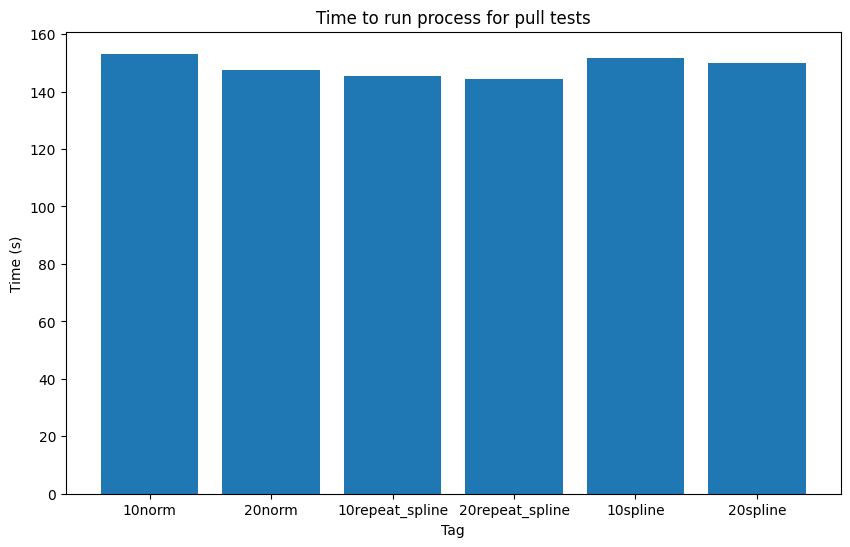

In [14]:
plt.figure(figsize=(10, 6))
plt.bar([t[9:] for t in tags], pulltest_process_times)
plt.xlabel('Tag')
plt.ylabel('Time (s)')
plt.title('Time to run process for pull tests')
plt.ylim(0,)
plt.show()

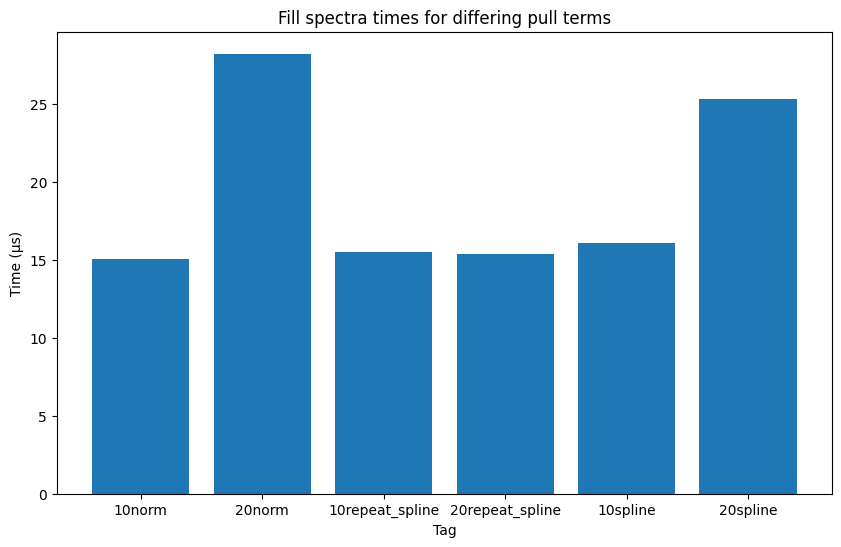

In [15]:
plt.figure(figsize=(10, 6))
plt.bar([t[9:] for t in tags], pulltest_fill_spectra_times)
plt.xlabel('Tag')
plt.ylabel('Time (μs)')
plt.title('Fill spectra times for differing pull terms')
plt.ylim(0,)
plt.show()

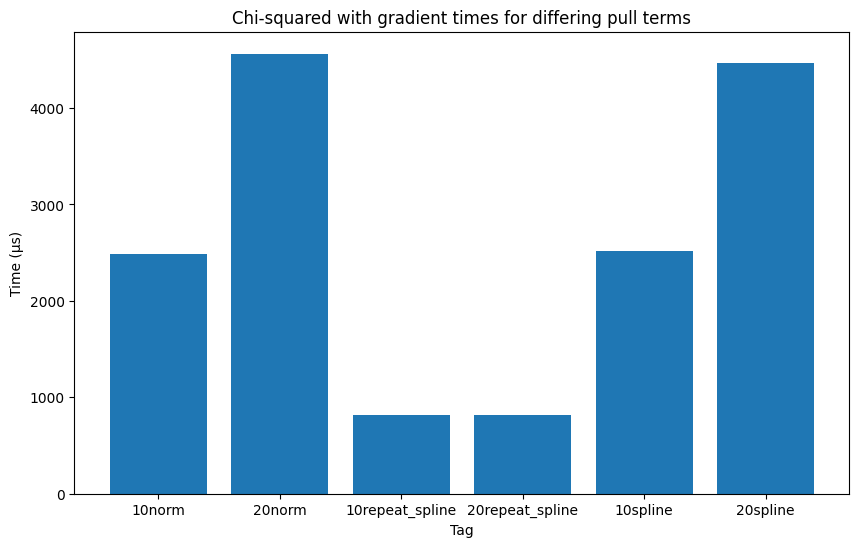

In [16]:
plt.figure(figsize=(10, 6))
plt.bar([t[9:] for t in tags], pulltest_chi2_with_grad_times)
plt.xlabel('Tag')
plt.ylabel('Time (μs)')
plt.title('Chi-squared with gradient times for differing pull terms')
plt.ylim(0,)
plt.show()

In [ ]:
def linear_func(x, a, b):
    return a * x + b

spec_linear_params, spec_linear_covar = curve_fit(linear_func, valid_fill_spectra_all_times_points[:, 1], fill_spectra_all_times)
spec_linear_residuals = fill_spectra_all_times - linear_func(valid_fill_spectra_all_times_points[:, 1], *spec_linear_params)
spec_linear_ss_res = np.sum(spec_linear_residuals**2)
spec_linear_ss_tot = np.sum((fill_spectra_all_times - np.mean(fill_spectra_all_times))**2)
spec_linear_r_squared = 1 - (spec_linear_ss_res / spec_linear_ss_tot)

chi_linear_params, chi_linear_covar = curve_fit(linear_func, valid_chi2_with_grad_times_points[:, 1], chi2_with_grad_times)
chi_linear_residuals = chi2_with_grad_times - linear_func(valid_chi2_with_grad_times_points[:, 1], *chi_linear_params)
chi_linear_ss_res = np.sum(chi_linear_residuals**2)
chi_linear_ss_tot = np.sum((chi2_with_grad_times - np.mean(chi2_with_grad_times))**2)
chi_linear_r_squared = 1 - (chi_linear_ss_res / chi_linear_ss_tot)

ValueError: operands could not be broadcast together with shapes (28,) (27,) 

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(valid_process_times_points[:, 1], process_times)
plt.xlabel('Number of pulls')
plt.ylabel('Time (s)')
plt.title('Time to run process for varying number of pulls')
plt.ylim(0,)
plt.show()

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(valid_fill_spectra_all_times_points[:, 1], fill_spectra_all_times)
plt.plot(sorted(valid_fill_spectra_all_times_points[:, 1]), linear_func(sorted(valid_fill_spectra_all_times_points[:, 1]), *spec_linear_params), label='linear fit y=%.2fx + %.2f   R²=%.4f' % (*tuple(spec_linear_params), spec_linear_r_squared))
plt.legend()
plt.xlabel('Number of pulls')
plt.ylabel('Time (μs)')
plt.title('Fill spectra times for varying number of pulls')
plt.ylim(0,)
plt.show()

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(valid_chi2_with_grad_times_points[:, 1], chi2_with_grad_times)
plt.plot(sorted(valid_chi2_with_grad_times_points[:, 1]), linear_func(sorted(valid_chi2_with_grad_times_points[:, 1]), *chi_linear_params), label='linear fit y=%.2fx + %.2f   R²=%.4f' % (*tuple(chi_linear_params), chi_linear_r_squared))
plt.legend()
plt.xlabel('Number of pulls')
plt.ylabel('Time (μs)')
plt.title('Chi-squared with gradient times for varying number of pulls')
plt.ylim(0,)
plt.show()

Issues: 
```
terminate called after throwing an instance of 'boost::archive::archive_exception'
  what():  input stream error
run.sh: line 19: 385130 Aborted                 (core dumped)
```
`grep: write error: No space left on device`
```
1 main || Default-CV collapsed bin 1230 has 0 expected events (<=0). Empty-bin would make CNP/stat covariance singular.
```